In [12]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("../data/processed/clean_nav_history.csv")

df['date'] = pd.to_datetime(df['date'])

print(df.info())
print(df.amfi_code)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB
None
0        100016
1        100016
2        100016
3        100016
4        100016
          ...  
45995    149324
45996    149324
45997    149324
45998    149324
45999    149324
Name: amfi_code, Length: 46000, dtype: int64


In [14]:
selected_funds = [
    '119551',
    '120503',
    '118632',
    '119092',
    '120841',
    '125497',
    '101206',
    '100033',
    '103504',
    '145678'
]
df = df[df['amfi_code'].isin(selected_funds)]

In [19]:
pivot_df = df.pivot_table(
    index='date',
    columns='amfi_code',
    values='nav'
)

returns_df = pivot_df.pct_change()

correlation_matrix = returns_df.corr()

print(correlation_matrix)


print(df.columns.tolist())
print(df.head(2))

Empty DataFrame
Columns: []
Index: []
['amfi_code', 'date', 'nav']
Empty DataFrame
Columns: [amfi_code, date, nav]
Index: []


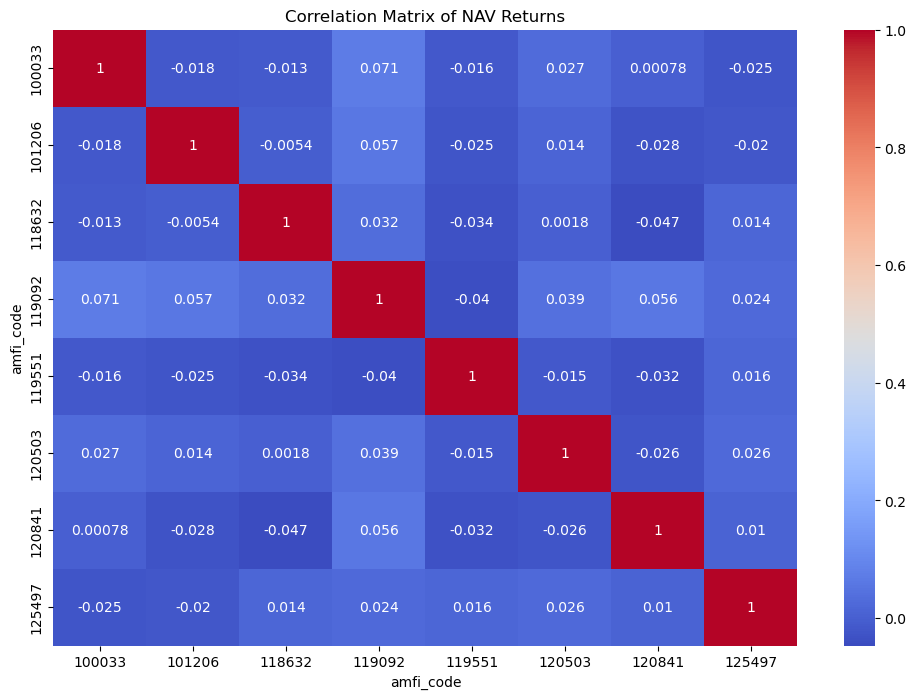

In [34]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix of NAV Returns")

plt.show()

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/clean_nav_history.csv")

df['date'] = pd.to_datetime(df['date'])

df = df.sort_values(
    by=['amfi_code', 'date']
)

df['daily_return'] = df.groupby(
    'amfi_code'
)['nav'].pct_change()

print(df[['amfi_code', 'date', 'nav', 'daily_return']].head())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210


In [8]:
def annualised_return(returns):
    
    returns = returns.dropna()
    
    n = len(returns)
    
    compounded_growth = (1 + returns).prod()
    
    annual_return = compounded_growth**(252/n) - 1
    
    return annual_return

annual_returns = df.groupby(
    'amfi_code'
)['daily_return'].apply(
    annualised_return
)

annual_returns = annual_returns.reset_index()

annual_returns.columns = [
    'amfi_code',
    'annualised_return'
]

print(annual_returns)

    amfi_code  annualised_return
0      100016           0.025435
1      100025           0.042987
2      100033           0.289279
3      101206           0.226265
4      101207           0.076502
5      101208           0.062739
6      102885           0.175404
7      102886           0.011304
8      102887           0.162055
9      118632           0.231161
10     118633           0.156614
11     118634           0.157567
12     118635           0.153571
13     118636           0.051259
14     119092           0.061381
15     119093           0.076105
16     119094           0.271025
17     119095           0.014678
18     119120           0.056773
19     119551           0.247966
20     119552           0.206968
21     119598           0.311266
22     119599           0.019818
23     120503           0.180708
24     120504           0.223935
25     120505           0.315124
26     120506           0.164394
27     120507           0.069752
28     120841           0.130283
29     120

In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/clean_nav_history.csv")

df['date'] = pd.to_datetime(df['date'])

df = df.sort_values(
    by=['amfi_code', 'date']
)

selected_funds = {
    '119551': 'SBI Bluechip',
    '125497': 'HDFC Top 100',
    '120503': 'ICICI Bluechip'
}

def calculate_cagr(nav_start, nav_end, years):
    
    cagr = ((nav_end / nav_start) ** (1 / years)) - 1
    
    return cagr

results = []

cagr_df = pd.DataFrame(results)

print(cagr_df)

Empty DataFrame
Columns: []
Index: []


In [33]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/clean_nav_history.csv")


df['date'] = pd.to_datetime(df['date'])

df = df.sort_values(
    by=['amfi_code', 'date']
)

df['daily_return'] = df.groupby(
    'amfi_code'
)['nav'].pct_change()

rf_annual = 0.065

rf_daily = rf_annual / 252

print(df.info)

def sharpe_ratio(returns):
    
    returns = returns.dropna()
    
    excess_returns = returns - rf_daily
    
    mean_excess_return = excess_returns.mean()
    
    std_return = returns.std()
    
    sharpe_daily = mean_excess_return / std_return
    
    sharpe_annual = sharpe_daily * np.sqrt(252)
    
    return sharpe_annual

def sharpe_ratio(returns):
    
    returns = returns.dropna()
    
    excess_returns = returns - rf_daily
    
    mean_excess_return = excess_returns.mean()
    
    std_return = returns.std()
    
    sharpe_daily = mean_excess_return / std_return
    
    sharpe_annual = sharpe_daily * np.sqrt(252)
    
    return sharpe_annual

sharpe_df = df.groupby(
    'amfi_code'
)['daily_return'].apply(
    sharpe_ratio
)

sharpe_df = sharpe_df.reset_index()

sharpe_df.columns = [
    'amfi_code',
    'sharpe_ratio'
]

print(sharpe_df)

<bound method DataFrame.info of        amfi_code       date       nav  daily_return
0         100016 2022-01-03  520.4608           NaN
1         100016 2022-01-04  515.0971     -0.010306
2         100016 2022-01-05  521.7239      0.012865
3         100016 2022-01-06  515.7880     -0.011377
4         100016 2022-01-07  515.1639     -0.001210
...          ...        ...       ...           ...
45995     149324 2026-05-25  292.4810      0.012106
45996     149324 2026-05-26  291.2707     -0.004138
45997     149324 2026-05-27  288.8007     -0.008480
45998     149324 2026-05-28  280.6873     -0.028093
45999     149324 2026-05-29  279.7511     -0.003335

[46000 rows x 4 columns]>
    amfi_code  sharpe_ratio
0      100016     -0.201517
1      100025     -0.567095
2      100033      1.093699
3      101206      1.027213
4      101207      0.162661
5      101208     -0.815567
6      102885      0.817099
7      102886     -0.205832
8      102887      0.619518
9      118632      1.081659
10     11

In [34]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/clean_nav_history.csv")

df['date'] = pd.to_datetime(df['date'])

df = df.sort_values(
    by=['amfi_code', 'date']
)

df['daily_return'] = df.groupby(
    'amfi_code'
)['nav'].pct_change()

rf_annual = 0.065
rf_daily = rf_annual / 252

def sortino_ratio(returns):
    
    returns = returns.dropna()
    
    excess_returns = returns - rf_daily
    
    downside_returns = excess_returns[
        excess_returns < 0
    ]
    
    downside_std = downside_returns.std()
    
    mean_excess_return = excess_returns.mean()
    
    sortino_daily = mean_excess_return / downside_std
    
    sortino_annual = sortino_daily * np.sqrt(252)
    
    return sortino_annual

sortino_df = df.groupby(
    'amfi_code'
)['daily_return'].apply(
    sortino_ratio
)

sortino_df = sortino_df.reset_index()

sortino_df.columns = [
    'amfi_code',
    'sortino_ratio'
]

print(sortino_df)

    amfi_code  sortino_ratio
0      100016      -0.348196
1      100025      -0.915371
2      100033       1.823824
3      101206       1.785592
4      101207       0.274615
5      101208      -1.324583
6      102885       1.418194
7      102886      -0.344973
8      102887       1.079016
9      118632       1.839859
10     118633       1.140144
11     118634       0.744123
12     118635       1.130602
13     118636      -0.599017
14     119092       0.051908
15     119093       0.219528
16     119094       1.698390
17     119095      -0.127050
18     119120      -0.366523
19     119551       2.103952
20     119552       1.603981
21     119598       1.661245
22     119599      -0.094080
23     120503       1.329023
24     120504       1.785043
25     120505       2.010035
26     120506       1.088341
27     120507       0.827574
28     120841       0.854822
29     120842       0.123519
30     120843       2.352942
31     120844      -0.147815
32     125497       1.311160
33     125498 

In [46]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

fund_df = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

benchmark_df = pd.read_csv(
    "../data/processed/clean_benchmark_indices.csv"
)

fund_df['date'] = pd.to_datetime(fund_df['date'])

benchmark_df['date'] = pd.to_datetime(
    benchmark_df['date']
)

fund_df = fund_df.sort_values(
    by=['amfi_code', 'date']
)

fund_df['fund_return'] = fund_df.groupby(
    'amfi_code'
)['nav'].pct_change()

print(benchmark_df.info)

benchmark_df = benchmark_df.sort_values('date')

benchmark_df['benchmark_return'] = benchmark_df[
    'close_value'
].pct_change()

benchmark_df = benchmark_df.sort_values('date')

benchmark_df['benchmark_return'] = benchmark_df[
    'close_value'
].pct_change()

selected_code = '119551'

single_fund = fund_df[
    fund_df['amfi_code'] == selected_code
]

merged_df = pd.merge(
    single_fund[['date', 'fund_return']],
    benchmark_df[['date', 'benchmark_return']],
    on='date'
)

merged_df = merged_df.dropna()

result = linregress(
    merged_df['benchmark_return'],
    merged_df['fund_return']
)

beta = result.slope

daily_alpha = result.intercept

annual_alpha = daily_alpha * 252


print("Beta:", beta)

print("Annualized Alpha:", annual_alpha)

<bound method DataFrame.info of            date   index_name  close_value
0    2022-01-03      NIFTY50     17492.79
1    2022-01-04      NIFTY50     17689.64
2    2022-01-05      NIFTY50     17835.05
3    2022-01-06      NIFTY50     17878.51
4    2022-01-07      NIFTY50     17759.15
...         ...          ...          ...
8045 2026-05-25  CRISIL_GILT      2278.26
8046 2026-05-26  CRISIL_GILT      2281.42
8047 2026-05-27  CRISIL_GILT      2281.30
8048 2026-05-28  CRISIL_GILT      2298.35
8049 2026-05-29  CRISIL_GILT      2302.79

[8050 rows x 3 columns]>
Beta: nan
Annualized Alpha: nan


C:\Users\Radiusr\AppData\Local\Temp\ipykernel_11968\3273594465.py:55: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  result = linregress(


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/clean_nav_history.csv")

df['date'] = pd.to_datetime(df['date'])

df = df.sort_values(
    by=['amfi_code', 'date']
)

results = []

for code in df['amfi_code'].unique():
    
    fund_df = df[
        df['amfi_code'] == code
    ].copy()


    fund_df['running_max'] = fund_df[
        'nav'
    ].cummax()   

    fund_df['drawdown'] = (
        fund_df['nav'] /
        fund_df['running_max']
    ) - 1

    max_dd = fund_df['drawdown'].min()

    worst_row = fund_df.loc[
        fund_df['drawdown'].idxmin()
    ]

    worst_date = worst_row['date']

    results.append({
        'amfi_code': code,
        'max_drawdown': max_dd,
        'worst_drawdown_date': worst_date
    })

mdd_df = pd.DataFrame(results)

mdd_df['max_drawdown_pct'] = (
    mdd_df['max_drawdown'] * 100
)

print(mdd_df)

    amfi_code  max_drawdown worst_drawdown_date  max_drawdown_pct
0      100016     -0.247344          2022-09-15        -24.734441
1      100025     -0.043083          2023-07-28         -4.308264
2      100033     -0.162172          2022-05-12        -16.217209
3      101206     -0.112916          2023-07-05        -11.291596
4      101207     -0.354469          2026-05-11        -35.446916
5      101208     -0.001622          2023-09-12         -0.162250
6      102885     -0.108599          2022-03-29        -10.859862
7      102886     -0.280011          2026-04-27        -28.001124
8      102887     -0.215398          2022-07-04        -21.539827
9      118632     -0.174141          2024-07-19        -17.414075
10     118633     -0.186297          2024-02-29        -18.629743
11     118634     -0.233449          2026-02-20        -23.344886
12     118635     -0.116506          2022-06-09        -11.650625
13     118636     -0.083164          2024-02-09         -8.316362
14     119

Index(['amfi_code', 'date', 'nav'], dtype='object')
Index(['date', 'index_name', 'close_value'], dtype='object')
['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


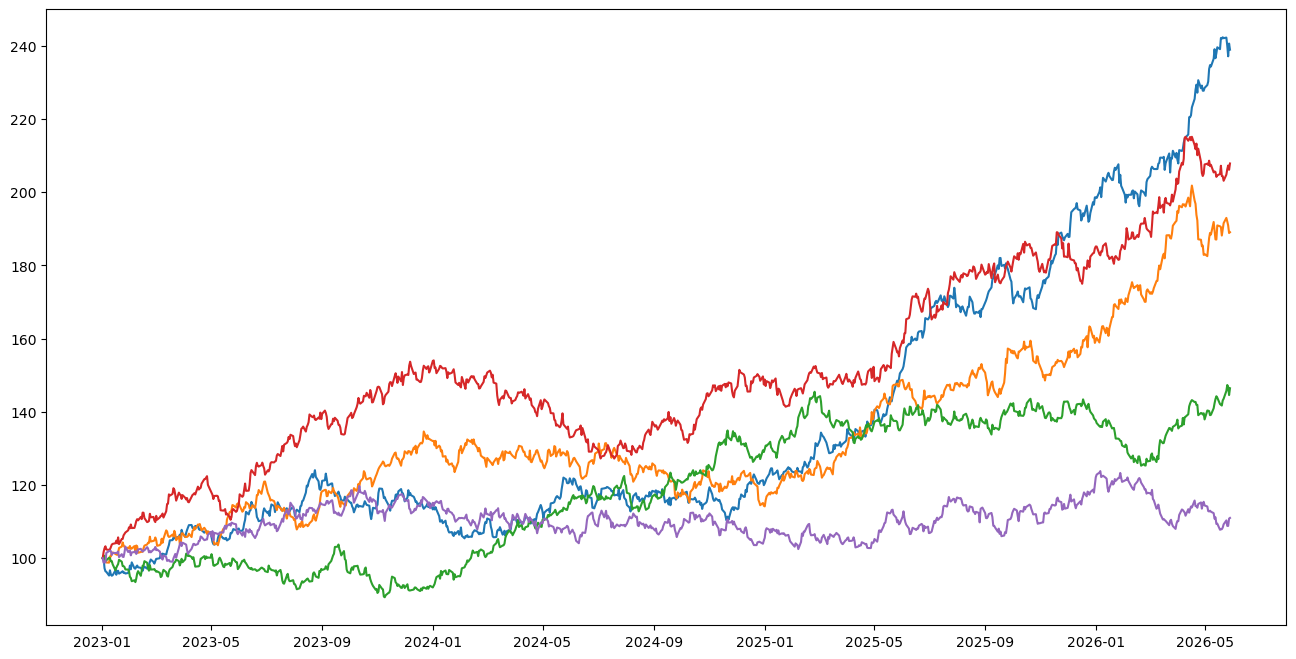

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


fund_df = pd.read_csv("../data/processed/clean_nav_history.csv")
benchmark_df = pd.read_csv("../data/processed/clean_benchmark_indices.csv")

print(fund_df.columns)
print(benchmark_df.columns)


fund_df['date'] = pd.to_datetime(fund_df['date'])
benchmark_df['date'] = pd.to_datetime(benchmark_df['date'])

fund_df['amfi_code'] = fund_df['amfi_code'].astype(str)


start_date = '2023-01-01'
fund_df = fund_df[fund_df['date'] >= start_date]
benchmark_df = benchmark_df[benchmark_df['date'] >= start_date]


top_funds = [
    '119551',
    '125497',
    '120503',
    '118632',
    '119092'
]

print(
    benchmark_df['index_name'].unique()
)

nifty50_df = benchmark_df[
    benchmark_df['index_name'] == 'Nifty 50'
]

nifty100_df = benchmark_df[
    benchmark_df['index_name'] == 'Nifty 100'
]

def normalize(series):

    return (
        series / series.iloc[0]
    ) * 100

plt.figure(figsize=(16,8))

for code in top_funds:

    temp = fund_df[
        fund_df['amfi_code'] == code
    ].copy()

    temp = temp.sort_values('date')

    temp['normalized_nav'] = normalize(
        temp['nav']
    )

    plt.plot(

        temp['date'],

        temp['normalized_nav'],

        label=code

    )

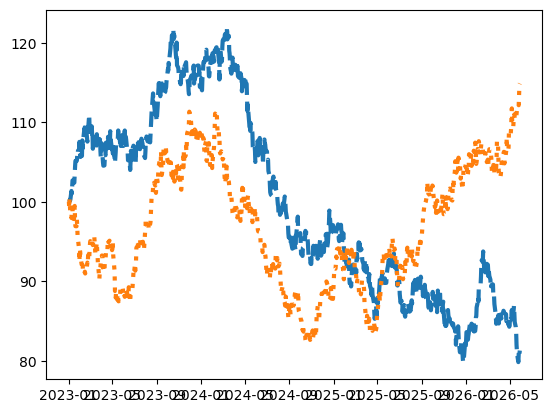

In [111]:
nifty50_df = nifty50_df.sort_values(
    'date'
)

nifty50_df['normalized_close'] = normalize(

    nifty50_df['close_value']

)

nifty100_df = nifty100_df.sort_values(
    'date'
)

nifty100_df['normalized_close'] = normalize(

    nifty100_df['close_value']

)

plt.plot(

    nifty50_df['date'],

    nifty50_df['normalized_close'],

    linewidth=3,

    linestyle='--',

    label='NIFTY50'

)

plt.plot(

    nifty100_df['date'],

    nifty100_df['normalized_close'],

    linewidth=3,

    linestyle=':',

    label='NIFTY100'

)

fund_df = fund_df.sort_values(
    by=['amfi_code', 'date']
)

fund_df['fund_return'] = fund_df.groupby(
    'amfi_code'
)['nav'].pct_change()

In [116]:
fund_df = fund_df.sort_values(
    by=['amfi_code', 'date']
)

fund_df['fund_return'] = fund_df.groupby(
    'amfi_code'
)['nav'].pct_change()

nifty100_df['benchmark_return'] = (

    nifty100_df['close_value']

    .pct_change()

)

tracking_results = []

for code in top_funds:

    temp = fund_df[

        fund_df['amfi_code'] == code

    ][
        ['date', 'fund_return']
    ]

    merged = pd.merge(

        temp,

        nifty100_df[
            ['date', 'benchmark_return']
        ],

        on='date'

    )

    merged = merged.dropna()

    merged['active_return'] = (

        merged['fund_return']

        -

        merged['benchmark_return']

    )

    tracking_error = (

        merged['active_return'].std()

        * np.sqrt(252)

    )

    tracking_results.append({

        'amfi_code': code,

        'tracking_error': tracking_error

    })

    tracking_df = pd.DataFrame(
    tracking_results
)

print(tracking_df)

  amfi_code  tracking_error
0    119551        0.192439
1    125497        0.190274
2    120503        0.188337
3    118632        0.192170
4    119092        0.185817
